# First Neural Network on Images

This notebook trains an MLP classifier on Fashion-MNIST, demonstrating the complete training pipeline: data loading, preprocessing, model definition, training with validation, and evaluation.

In [1]:
import torch
from torch import nn
from torch import optim
from torchvision import transforms, datasets
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.sampler import SubsetRandomSampler
import numpy as np
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

PyTorch version: 2.10.0+cu128
Using device: cuda


In [2]:
# (device configuration is in the cell above)

# Let's start by loading the training set of fashion MNIST. PyTorch has a number of functions to load popular datasets in 'torchvision.datasets'. The training set contains 60,000 grayscale images, each 28x28 pixels.

In [3]:
trainset = datasets.FashionMNIST(root='../images', train=True, transform=None, download=True)

In [4]:
# Normalization: (0.5, 0.5) maps pixel values from [0,1] to [-1,1].
# This is a common simplification. For more accurate normalization,
# Fashion-MNIST has mean ~0.2860 and std ~0.3530.

FMNIST_MEAN = (0.5,)
FMNIST_STD  = (0.5,)

prep = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(FMNIST_MEAN, FMNIST_STD)   
])

class FMNistDataset(Dataset):
    def __init__(self, dataset, transform=None): 
        self.dataset   = dataset
        self.transform = transform

    def __getitem__(self, index):
        img, target = self.dataset[index]
        return self.transform(img), target

    def __len__(self):
        return len(self.dataset)

Images are 28x28x1


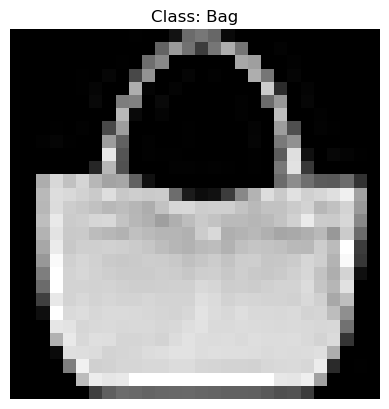

In [5]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

dataset   = FMNistDataset(trainset, prep)
(image, target) = dataset[100]
nchannels = image.shape[0]
height    = image.shape[1]
width     = image.shape[2]
print(f"Images are {width}x{height}x{nchannels}")

# Undo normalization for visualization
mean = torch.tensor(FMNIST_MEAN).view(1, 1, 1)
std  = torch.tensor(FMNIST_STD).view(1, 1, 1)
image_vis = (image * std + mean).clamp(0, 1)
image_vis = image_vis.squeeze(0).numpy()  # grayscale: remove channel dim

plt.imshow(image_vis, cmap='gray')
plt.title(f"Class: {class_names[target]}")
plt.axis('off')
plt.show()

## Let's split our training set into training, validation, and test sets by creating one data loader for each.

In [6]:
indices      = list(range(len(dataset)))
train_sample = SubsetRandomSampler(indices[:30000])
valid_sample = SubsetRandomSampler(indices[30000:45000])
test_sample  = SubsetRandomSampler(indices[45000:])
trainloader  = DataLoader(dataset,sampler=train_sample,batch_size=64)
validloader  = DataLoader(dataset,sampler=valid_sample,batch_size=64)
testloader   = DataLoader(dataset,sampler=test_sample,batch_size=64)

# Create your first NN on images

Since this categorical image classification problem is simple, you may start by flattening the input images into feature vectors to be the input of an MLP classifier.

In [7]:
class FMNistNet(nn.Module):

    def __init__(self, input_shape, nclasses=10):
        super().__init__()
        
        # MLP classifier: flatten -> dense layers with dropout
        self.classifier = nn.Sequential(
            nn.Linear(in_features=input_shape[1]*input_shape[2], out_features=300, bias=True),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(in_features=300, out_features=100, bias=True),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(100, nclasses)
        )

        self.weights_init()

    def forward(self, x):
        # Flatten image into a vector (keep batch dimension)
        x = torch.flatten(x, start_dim=1)
        y = self.classifier(x)
        return y
  
    def weights_init(self):
        for x in self.modules():
            if isinstance(x, nn.Linear):
                torch.nn.init.xavier_uniform_(x.weight.data)
                if (x.bias is not None): 
                    x.bias.data.zero_()

# Build the model and define criterion and optimizer

In [8]:
# Create loss function once (not per batch)
ce_loss = nn.CrossEntropyLoss()

def Criterion(preds, targets):
    loss        = ce_loss(preds, targets.long()) 
    pred_labels = torch.argmax(preds, dim=1)
    acc         = torch.sum(pred_labels == targets.data).item() / pred_labels.size(0)
    return loss, acc
    
# Create the model with cross entropy loss and Adam optimizer
model     = FMNistNet((nchannels, height, width)).to(device)
print(model)
criterion = Criterion
optimizer = optim.Adam(model.parameters(), lr=1e-3)

FMNistNet(
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=300, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.25, inplace=False)
    (6): Linear(in_features=100, out_features=10, bias=True)
  )
)


# Train the model and report the results 

In [9]:
def train_batch(model, data, optimizer, criterion, device):
    model.train()
    ims, targets = data
    ims     = ims.to(device)
    targets = targets.to(device)
    
    optimizer.zero_grad()          # 1. reset gradients
    preds      = model(ims)        # 2. forward pass
    loss, acc  = criterion(preds, targets)  # 3. compute loss
    loss.backward()                # 4. backward pass
    optimizer.step()               # 5. update weights
    return loss.item(), acc

@torch.no_grad()
def validate_batch(model, data, criterion, device):
    model.eval()
    ims, targets = data
    ims     = ims.to(device)
    targets = targets.to(device)
    preds      = model(ims)
    loss, acc  = criterion(preds, targets)
    return loss.item(), acc

In [10]:
n_epochs = 40

# Track metrics
trn_losses, trn_accs = [], []
val_losses, val_accs = [], []

for epoch in range(n_epochs):
    # --- Training ---
    epoch_trn_loss, epoch_trn_acc, n_batches = 0, 0, 0
    for data in trainloader:
        loss, acc = train_batch(model, data, optimizer, criterion, device)
        epoch_trn_loss += loss
        epoch_trn_acc  += acc
        n_batches += 1
    trn_losses.append(epoch_trn_loss / n_batches)
    trn_accs.append(epoch_trn_acc / n_batches)

    # --- Validation ---
    epoch_val_loss, epoch_val_acc, n_batches = 0, 0, 0
    for data in validloader:
        loss, acc = validate_batch(model, data, criterion, device)
        epoch_val_loss += loss
        epoch_val_acc  += acc
        n_batches += 1
    val_losses.append(epoch_val_loss / n_batches)
    val_accs.append(epoch_val_acc / n_batches)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{n_epochs} — "
              f"Train loss: {trn_losses[-1]:.4f}, acc: {trn_accs[-1]:.4f} | "
              f"Val loss: {val_losses[-1]:.4f}, acc: {val_accs[-1]:.4f}")

Epoch  10/40 — Train loss: 0.3249, acc: 0.8807 | Val loss: 0.3403, acc: 0.8802
Epoch  20/40 — Train loss: 0.2620, acc: 0.9011 | Val loss: 0.3335, acc: 0.8871
Epoch  30/40 — Train loss: 0.2188, acc: 0.9164 | Val loss: 0.3437, acc: 0.8902
Epoch  40/40 — Train loss: 0.1962, acc: 0.9254 | Val loss: 0.3837, acc: 0.8868


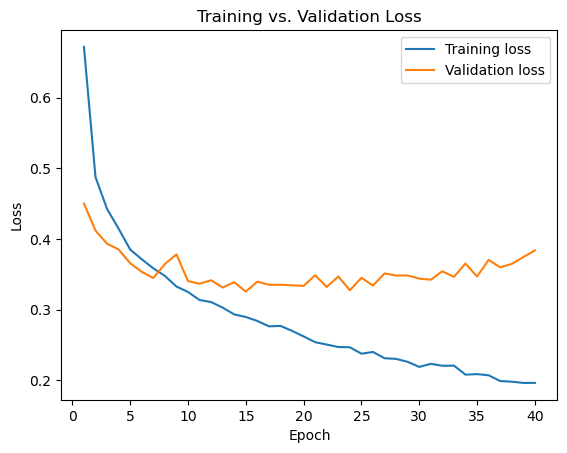

In [11]:
epochs = range(1, n_epochs + 1)
plt.plot(epochs, trn_losses, label='Training loss')
plt.plot(epochs, val_losses, label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs. Validation Loss')
plt.show()

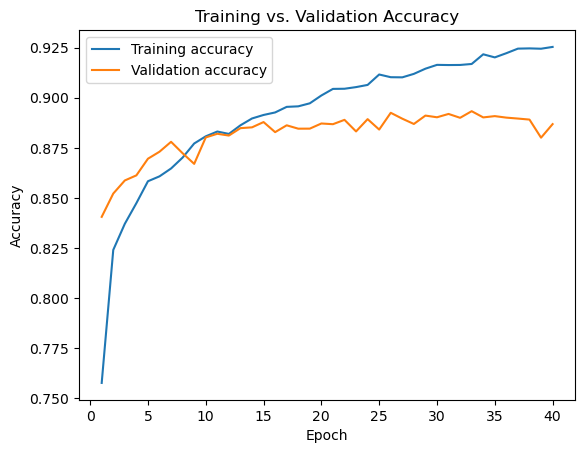

In [12]:
plt.plot(epochs, trn_accs, label='Training accuracy')
plt.plot(epochs, val_accs, label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs. Validation Accuracy')
plt.show()

# Evaluate the NN on the test set

In [13]:
mean_loss, mean_acc, n_batches = 0, 0, 0
for data in testloader:
    loss, acc  = validate_batch(model, data, criterion, device)
    mean_loss += loss
    mean_acc  += acc
    n_batches += 1
    
mean_loss /= n_batches
mean_acc  /= n_batches
print(f'Test loss: {mean_loss:.4f}, Test acc: {mean_acc:.4f}')

Test loss: 0.3939, Test acc: 0.8883


# Save the model

In [14]:
torch.save(model.to('cpu').state_dict(), "FMNistMLP.pth")

## Exercise

Observe the training and validation curves above. Is the model underfitting or overfitting?

Try the following modifications and observe the effect on the curves:
- Change the **learning rate** (e.g., try `1e-2`, `1e-4`).
- Change the **network architecture** (add/remove layers, change the number of neurons).
- Change the **dropout probability** (e.g., try `0.1`, `0.5`).
- Change the **batch size** and the **number of epochs**.
- Change the **train/validation/test split** proportions.

The goal is to find a configuration that achieves high accuracy on both training and validation sets without a large gap between them.